# Análise Estratégica de Dados — Credit Risk

Este notebook apresenta insights estratégicos para apoiar o desenvolvimento dos modelos de machine learning.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid')

conn = sqlite3.connect('../data/credit_risk.db')
df = pd.read_sql('SELECT * FROM credito_integrado', conn)

df['loan_int_rate'] = pd.to_numeric(df['loan_int_rate'], errors='coerce')
df['person_emp_length'] = pd.to_numeric(df['person_emp_length'], errors='coerce')
df['selic_media_num'] = pd.to_numeric(df['mes_num'], errors='coerce')

df['faixa_idade'] = pd.cut(df['person_age'], bins=[18,25,35,45,60,100], labels=['18-25','26-35','36-45','46-60','60+'])
df['faixa_renda'] = pd.cut(df['person_income'], bins=[0,30000,60000,100000,200000,6000000], labels=['<30k','30-60k','60-100k','100-200k','>200k'])
df['faixa_comprometimento'] = pd.cut(df['loan_percent_income'], bins=[0,0.1,0.2,0.3,0.5,1.0], labels=['<10%','10-20%','20-30%','30-50%','>50%'])
df['faixa_juros'] = pd.cut(df['loan_int_rate'], bins=[0,8,12,16,25], labels=['<8%','8-12%','12-16%','>16%'])

print('Base carregada:', df.shape)

Base carregada: (32581, 31)


---
## 1. Balanceamento do Target

**Insight:** A base tem 22% de inadimplentes — desbalanceamento moderado que justifica o uso de `class_weight='balanced'` nos modelos de classificação.

C:\Users\BB442HD\AppData\Local\Temp\ipykernel_10468\3398570843.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Adimplente (0)', 'Inadimplente (1)'], y=contagem.values, palette='Blues_r')


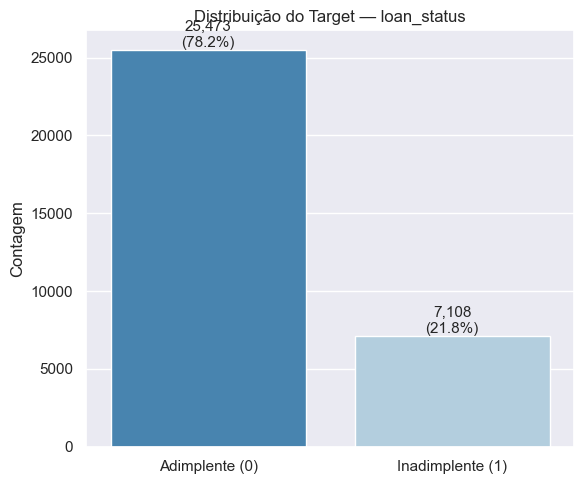

In [2]:
contagem = df['loan_status'].value_counts()

plt.figure(figsize=(6, 5))
sns.barplot(x=['Adimplente (0)', 'Inadimplente (1)'], y=contagem.values, palette='Blues_r')
plt.title('Distribuição do Target — loan_status')
plt.ylabel('Contagem')
for i, v in enumerate(contagem.values):
    plt.text(i, v + 200, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

---
## 2. Loan Grade — Principal Preditor de Risco

**Insight estratégico para o ML:** O `loan_grade` é a variável com maior poder discriminativo. Há um salto crítico entre grade C (21%) e grade D (59%) — esse ponto de corte deve ser capturado pelo modelo como uma fronteira de decisão importante.

C:\Users\BB442HD\AppData\Local\Temp\ipykernel_10468\3345968621.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=inadimplencia_grade.index, y=inadimplencia_grade.values, palette='coolwarm')


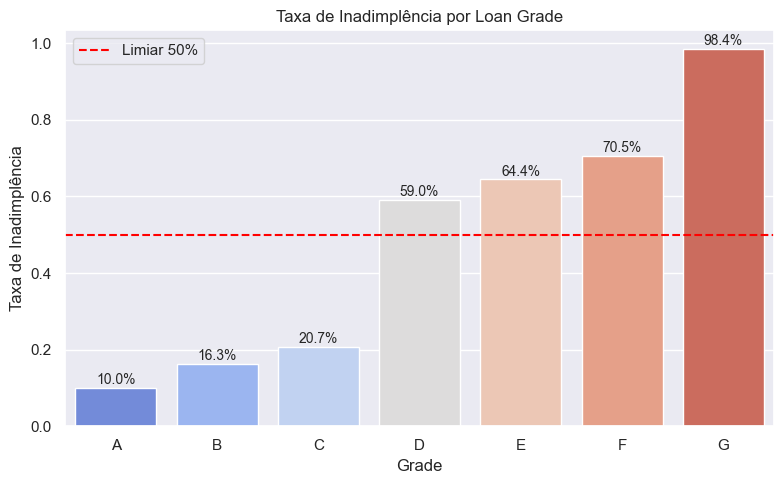

In [3]:
order_grade = ['A','B','C','D','E','F','G']
inadimplencia_grade = df.groupby('loan_grade')['loan_status'].mean().reindex(order_grade)

plt.figure(figsize=(8, 5))
bars = sns.barplot(x=inadimplencia_grade.index, y=inadimplencia_grade.values, palette='coolwarm')
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Limiar 50%')
plt.title('Taxa de Inadimplência por Loan Grade')
plt.xlabel('Grade')
plt.ylabel('Taxa de Inadimplência')
plt.legend()
for i, v in enumerate(inadimplencia_grade.values):
    plt.text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

---
## 3. Comprometimento de Renda — Gatilho de Alarme

**Insight estratégico para o ML:** Acima de 30% de comprometimento de renda, a inadimplência explode para ~70%. Essa variável deve ser tratada como um dos features mais importantes no modelo — considerar criar uma feature binária `alto_comprometimento` (1 se > 30%).

C:\Users\BB442HD\AppData\Local\Temp\ipykernel_10468\3947109584.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=inadimplencia_comp.index, y=inadimplencia_comp.values, palette='Reds')


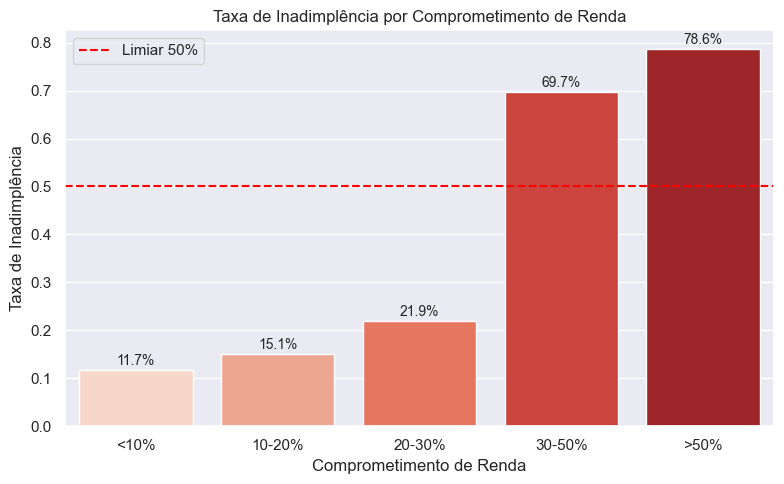

In [4]:
inadimplencia_comp = df.groupby('faixa_comprometimento', observed=True)['loan_status'].mean()

plt.figure(figsize=(8, 5))
bars = sns.barplot(x=inadimplencia_comp.index, y=inadimplencia_comp.values, palette='Reds')
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Limiar 50%')
plt.title('Taxa de Inadimplência por Comprometimento de Renda')
plt.xlabel('Comprometimento de Renda')
plt.ylabel('Taxa de Inadimplência')
plt.legend()
for i, v in enumerate(inadimplencia_comp.values):
    plt.text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

---
## 4. Renda — Fator Protetor

**Insight estratégico para o ML:** A renda tem correlação negativa com inadimplência (-0.14). Clientes com renda abaixo de R$30k têm 45% de chance de default — quase 5x mais que clientes acima de R$100k. A escala logarítmica de renda pode melhorar a performance do modelo.

C:\Users\BB442HD\AppData\Local\Temp\ipykernel_10468\927052559.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=inadimplencia_renda.index, y=inadimplencia_renda.values, palette='Blues_r')


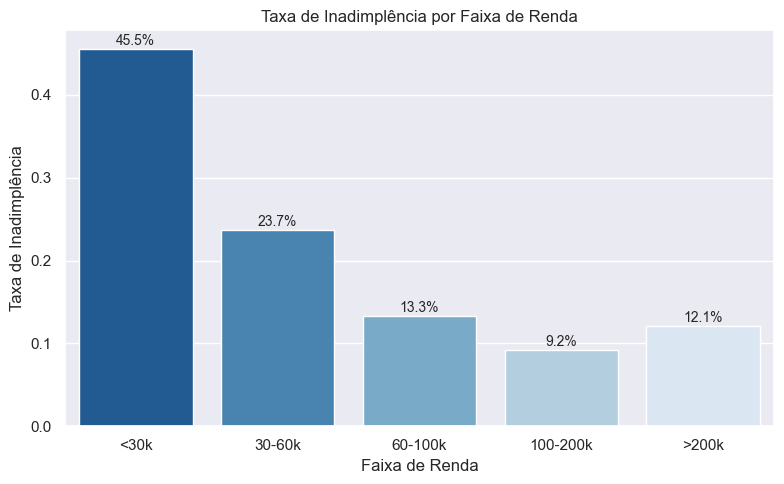

In [5]:
inadimplencia_renda = df.groupby('faixa_renda', observed=True)['loan_status'].mean()

plt.figure(figsize=(8, 5))
sns.barplot(x=inadimplencia_renda.index, y=inadimplencia_renda.values, palette='Blues_r')
plt.title('Taxa de Inadimplência por Faixa de Renda')
plt.xlabel('Faixa de Renda')
plt.ylabel('Taxa de Inadimplência')
for i, v in enumerate(inadimplencia_renda.values):
    plt.text(i, v + 0.005, f'{v:.1%}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

---
## 5. Taxa de Juros — Reflexo do Risco

**Insight estratégico para o ML:** A taxa de juros tem correlação de 0.33 com default — a segunda maior da base. Inadimplentes pagam em média 13.06% vs 10.44% dos adimplentes. Acima de 16% de juros, 63% dos clientes dão default.

C:\Users\BB442HD\AppData\Local\Temp\ipykernel_10468\3209594973.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=inadimplencia_juros.index, y=inadimplencia_juros.values, palette='Oranges')


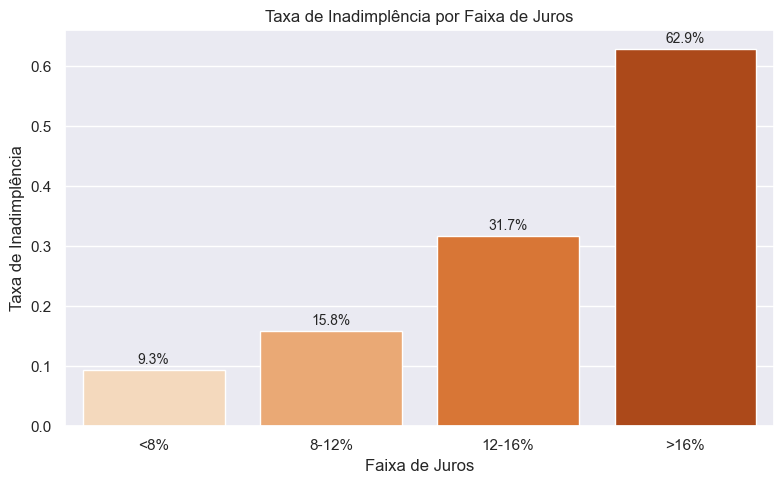

In [6]:
inadimplencia_juros = df.groupby('faixa_juros', observed=True)['loan_status'].mean()

plt.figure(figsize=(8, 5))
sns.barplot(x=inadimplencia_juros.index, y=inadimplencia_juros.values, palette='Oranges')
plt.title('Taxa de Inadimplência por Faixa de Juros')
plt.xlabel('Faixa de Juros')
plt.ylabel('Taxa de Inadimplência')
for i, v in enumerate(inadimplencia_juros.values):
    plt.text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

---
## 6. Situação de Moradia — Proxy de Estabilidade

**Insight estratégico para o ML:** Quem tem imóvel próprio inadimple 4x menos que quem aluga. Essa variável captura estabilidade patrimonial de forma eficiente e deve ser mantida no modelo.

C:\Users\BB442HD\AppData\Local\Temp\ipykernel_10468\363193313.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=inadimplencia_moradia.index, y=inadimplencia_moradia.values, palette='Blues_r')


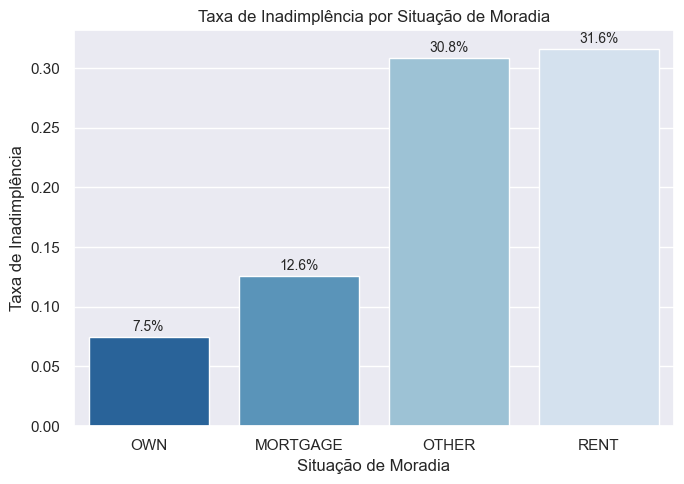

In [7]:
inadimplencia_moradia = df.groupby('person_home_ownership')['loan_status'].mean().sort_values()

plt.figure(figsize=(7, 5))
sns.barplot(x=inadimplencia_moradia.index, y=inadimplencia_moradia.values, palette='Blues_r')
plt.title('Taxa de Inadimplência por Situação de Moradia')
plt.xlabel('Situação de Moradia')
plt.ylabel('Taxa de Inadimplência')
for i, v in enumerate(inadimplencia_moradia.values):
    plt.text(i, v + 0.005, f'{v:.1%}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

---
## 7. Finalidade do Empréstimo

**Insight estratégico para o ML:** DEBTCONSOLIDATION (28.6%) e MEDICAL (26.7%) são as finalidades mais arriscadas — clientes que pedem crédito para pagar dívidas já estão em stress financeiro. VENTURE tem o menor risco (14.8%).

C:\Users\BB442HD\AppData\Local\Temp\ipykernel_10468\238463160.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=inadimplencia_intent.index, y=inadimplencia_intent.values, palette='coolwarm_r')


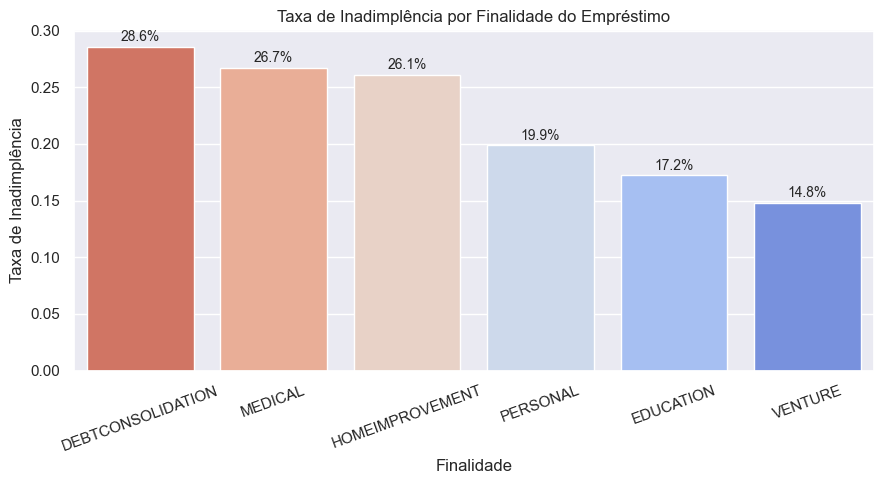

In [8]:
inadimplencia_intent = df.groupby('loan_intent')['loan_status'].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=inadimplencia_intent.index, y=inadimplencia_intent.values, palette='coolwarm_r')
plt.title('Taxa de Inadimplência por Finalidade do Empréstimo')
plt.xlabel('Finalidade')
plt.ylabel('Taxa de Inadimplência')
plt.xticks(rotation=20)
for i, v in enumerate(inadimplencia_intent.values):
    plt.text(i, v + 0.005, f'{v:.1%}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

---
## 8. Histórico de Default

**Insight estratégico para o ML:** Clientes com histórico de default têm o dobro de chance de inadimplir novamente (37.8% vs 18.4%). Feature binária de alto poder preditivo — comportamento passado é forte indicador do futuro.

C:\Users\BB442HD\AppData\Local\Temp\ipykernel_10468\962788654.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Sem histórico (N)', 'Com histórico (Y)'], y=inadimplencia_cb.values, palette=['steelblue','coral'])


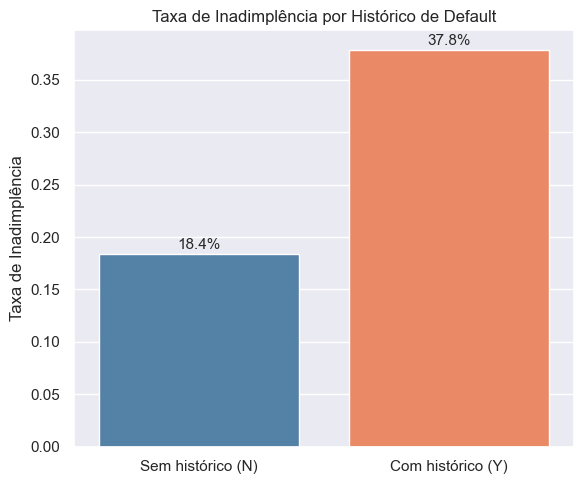

In [9]:
inadimplencia_cb = df.groupby('cb_person_default_on_file')['loan_status'].mean()

plt.figure(figsize=(6, 5))
sns.barplot(x=['Sem histórico (N)', 'Com histórico (Y)'], y=inadimplencia_cb.values, palette=['steelblue','coral'])
plt.title('Taxa de Inadimplência por Histórico de Default')
plt.ylabel('Taxa de Inadimplência')
for i, v in enumerate(inadimplencia_cb.values):
    plt.text(i, v + 0.005, f'{v:.1%}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

---
## 9. Interação: Grade × Moradia

**Insight estratégico para o ML:** A combinação de grade ruim com aluguel é extremamente perigosa. Grade D + RENT = 73.8% de inadimplência. Interações entre variáveis podem gerar features derivadas poderosas para o modelo.

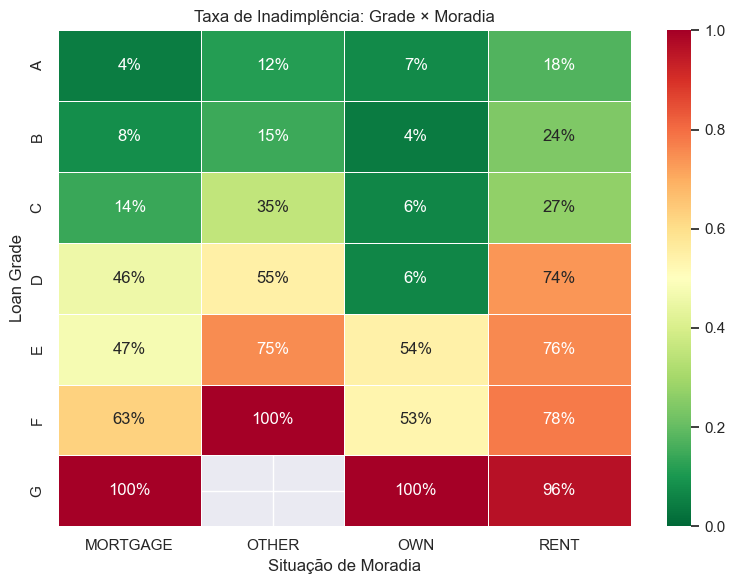

In [10]:
heatmap_data = df.groupby(['loan_grade','person_home_ownership'])['loan_status'].mean().unstack()
heatmap_data = heatmap_data.reindex(['A','B','C','D','E','F','G'])

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.0%', cmap='RdYlGn_r', linewidths=0.5, vmin=0, vmax=1)
plt.title('Taxa de Inadimplência: Grade × Moradia')
plt.xlabel('Situação de Moradia')
plt.ylabel('Loan Grade')
plt.tight_layout()
plt.show()

---
## 10. Interação: Renda × Grade

**Insight estratégico para o ML:** Mesmo com grade A, clientes de baixa renda têm 36% de inadimplência — muito acima da média do grade. Isso mostra que renda e grade juntos explicam o risco melhor do que cada um isolado.

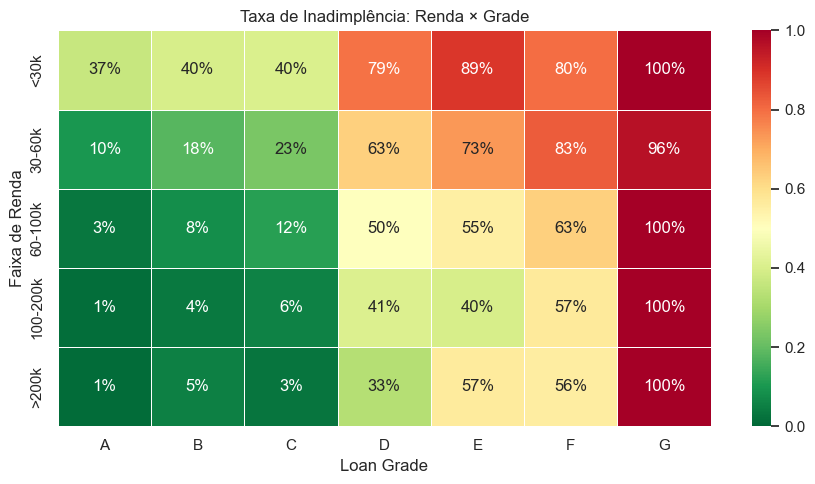

In [11]:
heatmap_renda_grade = df.groupby(['faixa_renda','loan_grade'], observed=True)['loan_status'].mean().unstack()
heatmap_renda_grade = heatmap_renda_grade.reindex(columns=['A','B','C','D','E','F','G'])

plt.figure(figsize=(9, 5))
sns.heatmap(heatmap_renda_grade, annot=True, fmt='.0%', cmap='RdYlGn_r', linewidths=0.5, vmin=0, vmax=1)
plt.title('Taxa de Inadimplência: Renda × Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Faixa de Renda')
plt.tight_layout()
plt.show()

---
## 11. Interação: Comprometimento × Grade

**Insight estratégico para o ML:** Comprometimento acima de 30% praticamente anula o benefício de um bom grade — grade A com >30% comprometimento já tem 60% de inadimplência. Essa interação é candidata forte a uma feature derivada no modelo.

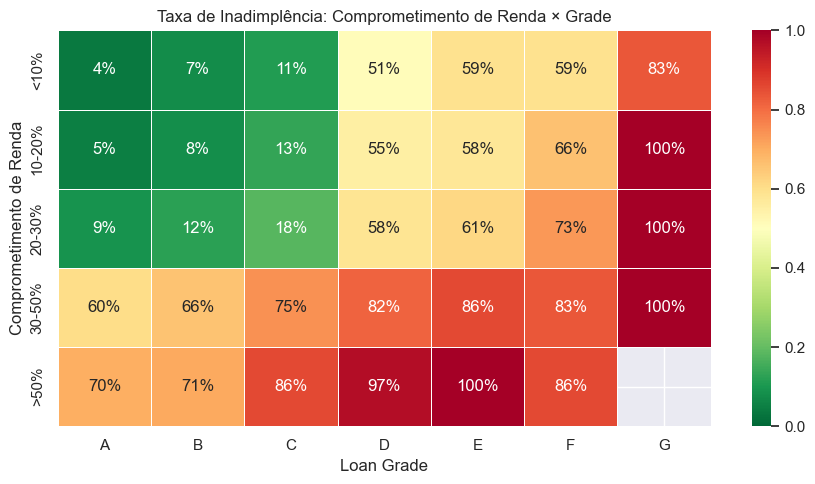

In [12]:
heatmap_comp_grade = df.groupby(['faixa_comprometimento','loan_grade'], observed=True)['loan_status'].mean().unstack()
heatmap_comp_grade = heatmap_comp_grade.reindex(columns=['A','B','C','D','E','F','G'])

plt.figure(figsize=(9, 5))
sns.heatmap(heatmap_comp_grade, annot=True, fmt='.0%', cmap='RdYlGn_r', linewidths=0.5, vmin=0, vmax=1)
plt.title('Taxa de Inadimplência: Comprometimento de Renda × Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Comprometimento de Renda')
plt.tight_layout()
plt.show()

---
## 12. Correlação entre Variáveis Numéricas

**Insight estratégico para o ML:** `loan_percent_income` (0.38) e `loan_int_rate` (0.33) são as features com maior correlação com o target. `person_income` tem correlação negativa (-0.14) — confirmando seu papel como fator protetor.

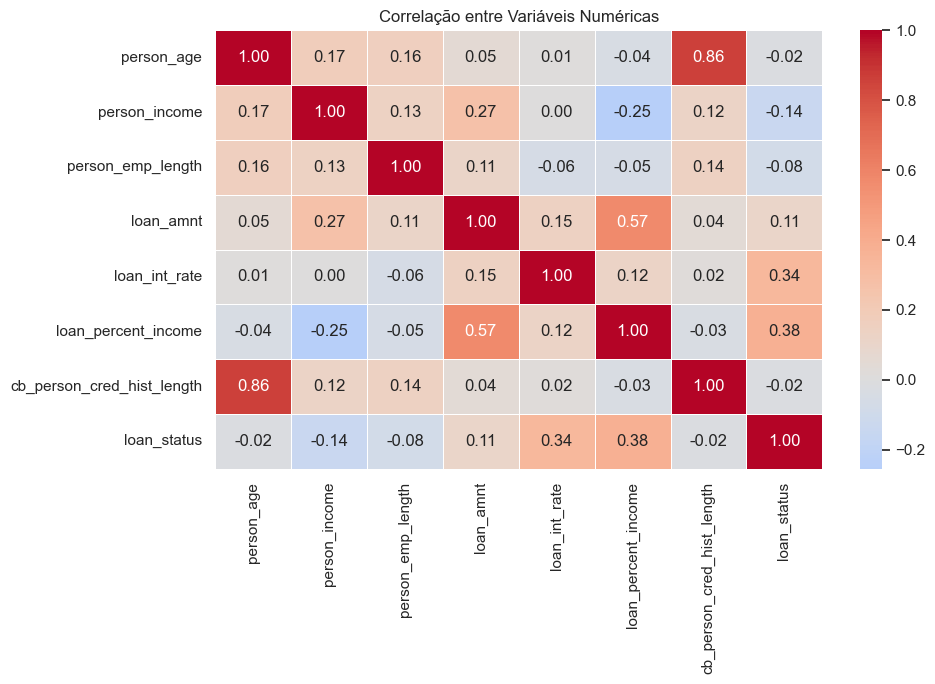

In [13]:
num_cols = ['person_age','person_income','person_emp_length','loan_amnt',
            'loan_int_rate','loan_percent_income','cb_person_cred_hist_length','loan_status']

plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlação entre Variáveis Numéricas')
plt.tight_layout()
plt.show()

---
## 13. Combinações de Altíssimo Risco

**Insight estratégico para o ML:** Grade E + DEBTCONSOLIDATION tem 100% de inadimplência na base. Essas combinações podem virar regras de negócio diretas — recusa automática independente do modelo.

C:\Users\BB442HD\AppData\Local\Temp\ipykernel_10468\1475021419.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=combo, x='mean', y='label', palette='Reds_r')


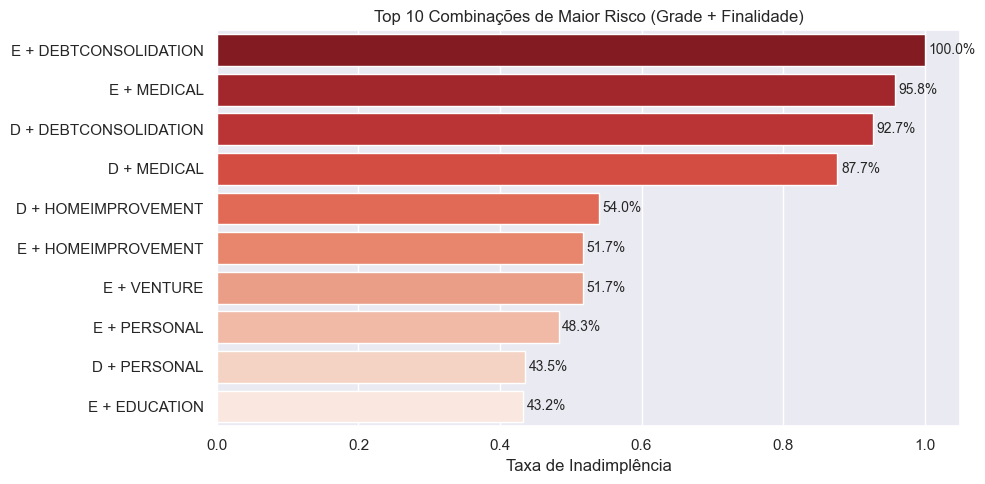

In [14]:
combo = df.groupby(['loan_grade','loan_intent'])['loan_status'].agg(['mean','count'])
combo = combo[combo['count'] > 100].sort_values('mean', ascending=False).head(10).reset_index()
combo['label'] = combo['loan_grade'] + ' + ' + combo['loan_intent']

plt.figure(figsize=(10, 5))
sns.barplot(data=combo, x='mean', y='label', palette='Reds_r')
plt.title('Top 10 Combinações de Maior Risco (Grade + Finalidade)')
plt.xlabel('Taxa de Inadimplência')
plt.ylabel('')
for i, v in enumerate(combo['mean']):
    plt.text(v + 0.005, i, f'{v:.1%}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

---
## 14. Resumo das Correlações com o Target

**Insight final:** Ranking das variáveis numéricas por poder preditivo — guia direto para seleção de features no modelo.

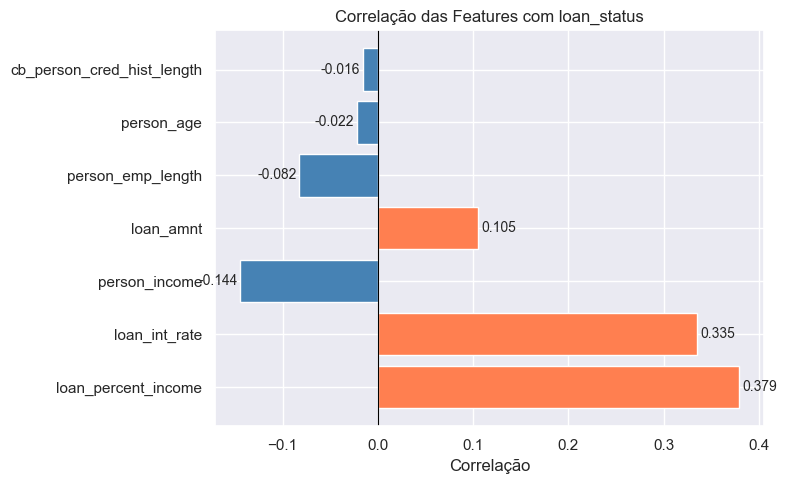

In [15]:
correlacoes = df[num_cols].corr()['loan_status'].drop('loan_status').sort_values(key=abs, ascending=False)

cores = ['coral' if v > 0 else 'steelblue' for v in correlacoes.values]

plt.figure(figsize=(8, 5))
plt.barh(correlacoes.index, correlacoes.values, color=cores)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Correlação das Features com loan_status')
plt.xlabel('Correlação')
for i, v in enumerate(correlacoes.values):
    plt.text(v + (0.003 if v > 0 else -0.003), i, f'{v:.3f}', va='center',
             ha='left' if v > 0 else 'right', fontsize=10)
plt.tight_layout()
plt.show()